# Dự đoán doanh số cửa hàng - Store Sales Forecasting

Notebook này sử dụng bộ dữ liệu mới trong `data/new_data` để dự đoán `sales` theo từng ngày, cửa hàng và nhóm sản phẩm.

Quy trình thực hiện:

| Bước | Nội dung |
| --- | --- |
| Bước 0 | Xác định bài toán và chiến lược đánh giá |
| Bước 1 | Đọc dữ liệu mới và kiểm tra schema |
| Bước 2 | EDA tổng quan: target, zero sales, family, thời gian, promotion |
| Bước 3 | Tạo đặc trưng thời gian, store, holiday, oil và lag/rolling sales |
| Bước 4 | Tạo tập train/validation theo thời gian |
| Bước 5 | Xây dựng metric và preprocessing pipeline |
| Bước 6 | So sánh baseline time-series |
| Bước 7 | Huấn luyện và so sánh mô hình ML |
| Bước 8 | Chẩn đoán mô hình bằng biểu đồ trong notebook |
| Bước 9 | Train final model và tạo bảng submission trong notebook |
| Bước 10 | Tổng kết kết quả và hướng cải thiện |

## Bước 0. Xác định bài toán

Mục tiêu là dự đoán doanh số `sales` cho từng tổ hợp:

```text
date × store_nbr × family
```

- Loại bài toán: time-series regression / demand forecasting.
- Biến mục tiêu: `sales`.
- Chỉ số đánh giá chính: RMSLE.
- Chỉ số phụ: MAE, RMSE, R2.
- Chiến lược validation: 16 ngày cuối của tập train, cùng độ dài với `test.csv`.

Điểm quan trọng: các đặc trưng lag/rolling phải được dịch ít nhất 16 ngày để không dùng doanh số của chính giai đoạn cần dự đoán.

In [68]:
from __future__ import annotations

import json
from pathlib import Path
from typing import Any

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.compose import ColumnTransformer
from sklearn.dummy import DummyRegressor
from sklearn.ensemble import HistGradientBoostingRegressor
from sklearn.impute import SimpleImputer
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, OrdinalEncoder, StandardScaler

pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda value: f"{value:,.4f}")

import seaborn as sns

# ── Plot style ──────────────────────────────────────────────
sns.set_theme(style="whitegrid", font_scale=1.2, palette="muted")
plt.rcParams.update({
    "figure.figsize": (12, 5),
    "figure.dpi": 100,
    "axes.titlesize": 14,
    "axes.titleweight": "bold",
    "axes.labelsize": 12,
})
COLORS = {
    "primary": "#4c78a8",
    "secondary": "#f58518",
    "tertiary": "#54a24b",
    "accent": "#e45756",
    "purple": "#b279a2",
    "teal": "#72b7b2",
}


In [69]:
import sys
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(PROJECT_ROOT / "src"))
DATA_DIR = PROJECT_ROOT / "data" / "new_data"

TRAIN_PATH = DATA_DIR / "train.csv"
TEST_PATH = DATA_DIR / "test.csv"
STORES_PATH = DATA_DIR / "stores.csv"
OIL_PATH = DATA_DIR / "oil.csv"
HOLIDAYS_PATH = DATA_DIR / "holidays_events.csv"
TRANSACTIONS_PATH = DATA_DIR / "transactions.csv"

TARGET = "sales"
DATE_COLUMN = "date"
VALIDATION_DAYS = 16
RECENT_TRAIN_DAYS = 365
RANDOM_STATE = 42

## Bước 1. Đọc dữ liệu

Bộ dữ liệu gồm các bảng chính:

- `train.csv`: doanh số lịch sử theo ngày, cửa hàng và nhóm sản phẩm.
- `test.csv`: horizon cần dự đoán.
- `stores.csv`: thông tin cửa hàng.
- `oil.csv`: giá dầu theo ngày.
- `holidays_events.csv`: ngày lễ/sự kiện.
- `transactions.csv`: số giao dịch theo cửa hàng/ngày, dùng cho EDA tham khảo.

In [70]:
train = pd.read_csv(TRAIN_PATH, parse_dates=[DATE_COLUMN])
test = pd.read_csv(TEST_PATH, parse_dates=[DATE_COLUMN])
stores = pd.read_csv(STORES_PATH)
oil = pd.read_csv(OIL_PATH, parse_dates=[DATE_COLUMN])
holidays = pd.read_csv(HOLIDAYS_PATH, parse_dates=[DATE_COLUMN])
transactions = pd.read_csv(TRANSACTIONS_PATH, parse_dates=[DATE_COLUMN])

summary = {
    "train_rows": len(train),
    "test_rows": len(test),
    "train_date_min": str(train[DATE_COLUMN].min().date()),
    "train_date_max": str(train[DATE_COLUMN].max().date()),
    "test_date_min": str(test[DATE_COLUMN].min().date()),
    "test_date_max": str(test[DATE_COLUMN].max().date()),
    "stores": int(train["store_nbr"].nunique()),
    "families": int(train["family"].nunique()),
}
summary

{'train_rows': 3000888,
 'test_rows': 28512,
 'train_date_min': '2013-01-01',
 'train_date_max': '2017-08-15',
 'test_date_min': '2017-08-16',
 'test_date_max': '2017-08-31',
 'stores': 54,
 'families': 33}

## Bước 2. EDA tổng quan
Trong phần này, chúng ta sẽ thực hiện phân tích khám phá dữ liệu (EDA) một cách chuyên sâu trên các bảng dữ liệu đã đọc: `train`, `stores`, `oil`, `holidays`, và `transactions`. Điều này sẽ giúp ta hiểu rõ các quy luật về xu hướng (trends), tính mùa vụ (seasonality), tác động của khuyến mại và các yếu tố bên ngoài (giá dầu, ngày lễ).

### 2.1 — Chất lượng dữ liệu & Giá trị khuyết thiếu (Missing Values)
Đầu tiên, chúng ta sẽ kiểm tra xem có các giá trị khuyết thiếu (null/missing) trong bất kỳ bảng dữ liệu nào không và nắm bắt kiểu dữ liệu của tập `train`.

Các cột có giá trị khuyết thiếu:


,DataFrame,Column,Missing Count,Percentage (%)
0,oil,dcoilwtico,43,3.53%


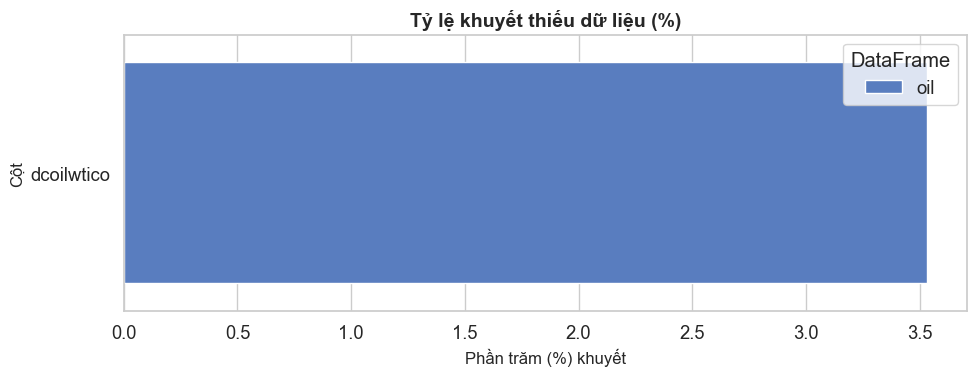

Kích thước tập train: (3000888, 6)

Kiểu dữ liệu của tập train:
id                      int64
date           datetime64[us]
store_nbr               int64
family                    str
sales                 float64
onpromotion             int64
dtype: object


In [71]:
# Kiểm tra missing values trong các DataFrame
dfs = {
    "train": train,
    "test": test,
    "stores": stores,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions
}

missing_data = []
for name, df in dfs.items():
    null_counts = df.isnull().sum()
    for col, count in null_counts.items():
        if count > 0:
            pct = (count / len(df)) * 100
            missing_data.append({"DataFrame": name, "Column": col, "Missing Count": count, "Percentage (%)": pct})

missing_df = pd.DataFrame(missing_data)
if not missing_df.empty:
    print("Các cột có giá trị khuyết thiếu:")
    missing_df_formatted = missing_df.copy()
    missing_df_formatted["Percentage (%)"] = missing_df_formatted["Percentage (%)"].map("{:.2f}%".format)
    display(missing_df_formatted)
    
    # Vẽ biểu đồ các cột bị thiếu
    plt.figure(figsize=(10, 4))
    sns.barplot(data=missing_df, x="Percentage (%)", y="Column", hue="DataFrame", palette="muted")
    plt.title("Tỷ lệ khuyết thiếu dữ liệu (%)")
    plt.xlabel("Phần trăm (%) khuyết")
    plt.ylabel("Cột")
    plt.tight_layout()
    plt.show()
else:
    print("Không có giá trị khuyết thiếu trong tất cả các bảng dữ liệu!")
    
# In thông tin cơ bản về train
print(f"Kích thước tập train: {train.shape}")
print("\nKiểu dữ liệu của tập train:")
print(train.dtypes)


### 2.2 — Phân phối của biến Target (Sales)
Phân tích phân phối của biến mục tiêu `sales` để xem độ lệch, sự xuất hiện của các giá trị ngoại lệ (outliers) và kiểm chứng hiệu quả của phép biến đổi logarit $log(1+x)$.

,count,mean,std,min,25%,50%,75%,max
sales,"3,000,888.0000",357.7757,"1,101.9977",0.0000,0.0000,11.0000,195.8473,"124,717.0000"
onpromotion,"3,000,888.0000",2.6028,12.2189,0.0000,0.0000,0.0000,0.0000,741.0000


Tỷ lệ doanh số bằng 0 (Zero sales share): 31.30%


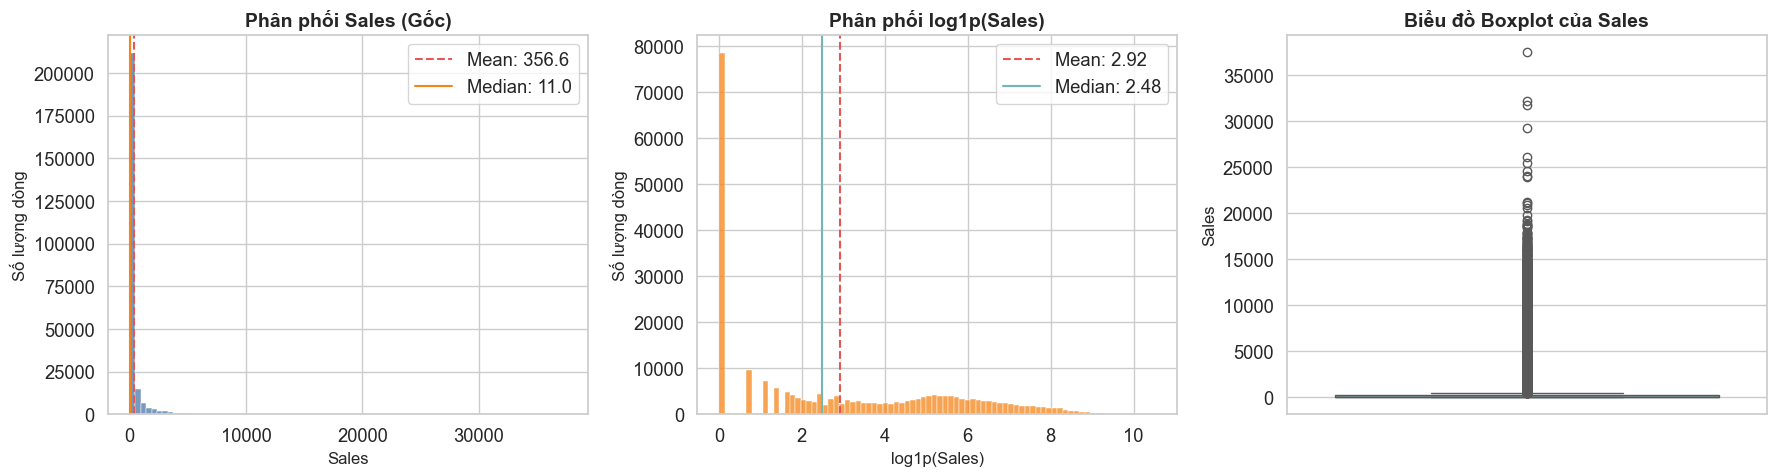

In [72]:
display(train[["sales", "onpromotion"]].describe().T)

zero_sales_pct = (train[TARGET] == 0).mean() * 100
print(f"Tỷ lệ doanh số bằng 0 (Zero sales share): {zero_sales_pct:.2f}%")

# Lấy mẫu ngẫu nhiên để vẽ đồ thị nhanh hơn
sample_sales = train[TARGET].sample(n=min(250_000, len(train)), random_state=RANDOM_STATE)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Phân phối doanh số gốc
sns.histplot(sample_sales, bins=80, color=COLORS["primary"], edgecolor="white", ax=axes[0], kde=False)
axes[0].set_title("Phân phối Sales (Gốc)")
axes[0].set_xlabel("Sales")
axes[0].set_ylabel("Số lượng dòng")
mean_val = sample_sales.mean()
median_val = sample_sales.median()
axes[0].axvline(mean_val, color=COLORS["accent"], linestyle="--", label=f"Mean: {mean_val:.1f}")
axes[0].axvline(median_val, color=COLORS["secondary"], linestyle="-", label=f"Median: {median_val:.1f}")
axes[0].legend()

# 2. Phân phối log1p(sales)
sns.histplot(np.log1p(sample_sales), bins=80, color=COLORS["secondary"], edgecolor="white", ax=axes[1], kde=False)
axes[1].set_title("Phân phối log1p(Sales)")
axes[1].set_xlabel("log1p(Sales)")
axes[1].set_ylabel("Số lượng dòng")
log_mean = np.log1p(sample_sales).mean()
log_median = np.log1p(sample_sales).median()
axes[1].axvline(log_mean, color=COLORS["accent"], linestyle="--", label=f"Mean: {log_mean:.2f}")
axes[1].axvline(log_median, color=COLORS["teal"], linestyle="-", label=f"Median: {log_median:.2f}")
axes[1].legend()

# 3. Box plot của Sales để xem outliers
sns.boxplot(y=sample_sales, ax=axes[2], color=COLORS["teal"])
axes[2].set_title("Biểu đồ Boxplot của Sales")
axes[2].set_ylabel("Sales")

plt.tight_layout()
plt.show()


### 2.3 — Phân tích theo nhóm sản phẩm (Product Family)
Tìm hiểu xem những nhóm sản phẩm nào đóng góp nhiều doanh số nhất và doanh số của các nhóm sản phẩm hàng đầu thay đổi thế nào qua các năm.

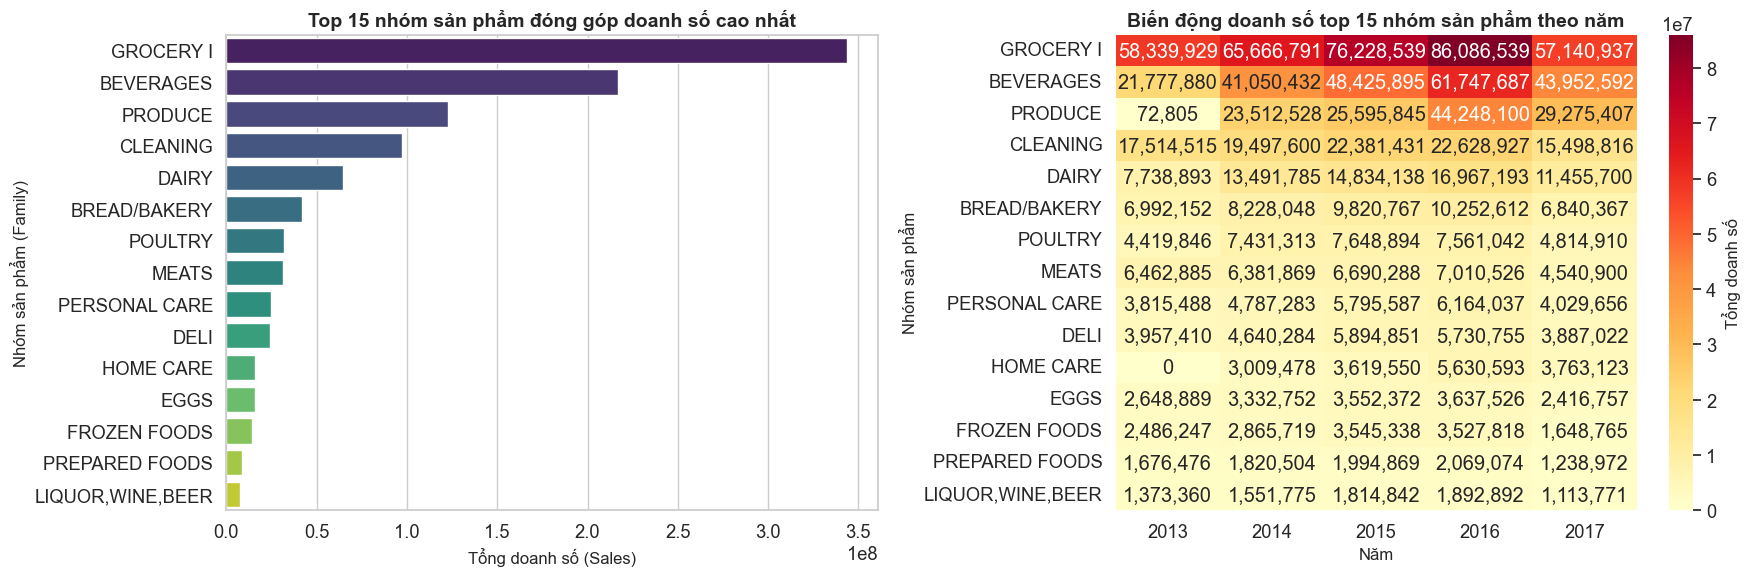

In [73]:
# Top 15 nhóm sản phẩm có doanh số cao nhất
family_sales = train.groupby("family", observed=True)[TARGET].sum().sort_values(ascending=False)
top_15_families = family_sales.head(15)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Bar chart ngang cho top 15
sns.barplot(x=top_15_families.values, y=top_15_families.index, ax=axes[0], palette="viridis", hue=top_15_families.index, legend=False)
axes[0].set_title("Top 15 nhóm sản phẩm đóng góp doanh số cao nhất")
axes[0].set_xlabel("Tổng doanh số (Sales)")
axes[0].set_ylabel("Nhóm sản phẩm (Family)")

# Thêm biến năm để vẽ heatmap xu hướng
train_copy = train.copy()
train_copy["year"] = train_copy[DATE_COLUMN].dt.year
family_year_sales = train_copy.pivot_table(
    values=TARGET, 
    index="family", 
    columns="year", 
    aggfunc="sum",
    observed=True
).loc[top_15_families.index]

# Heatmap phân phối theo năm
sns.heatmap(family_year_sales, annot=True, fmt=",.0f", cmap="YlOrRd", ax=axes[1], cbar_kws={'label': 'Tổng doanh số'})
axes[1].set_title("Biến động doanh số top 15 nhóm sản phẩm theo năm")
axes[1].set_xlabel("Năm")
axes[1].set_ylabel("Nhóm sản phẩm")

plt.tight_layout()
plt.show()


### 2.4 — Xu hướng doanh số theo thời gian (Trend & Seasonality)
Phân tích hành vi doanh số theo các chu kỳ thời gian khác nhau để nắm bắt xu hướng tăng trưởng dài hạn, tính mùa vụ hàng tuần và phân phối chi tiết theo từng tháng trong các năm.

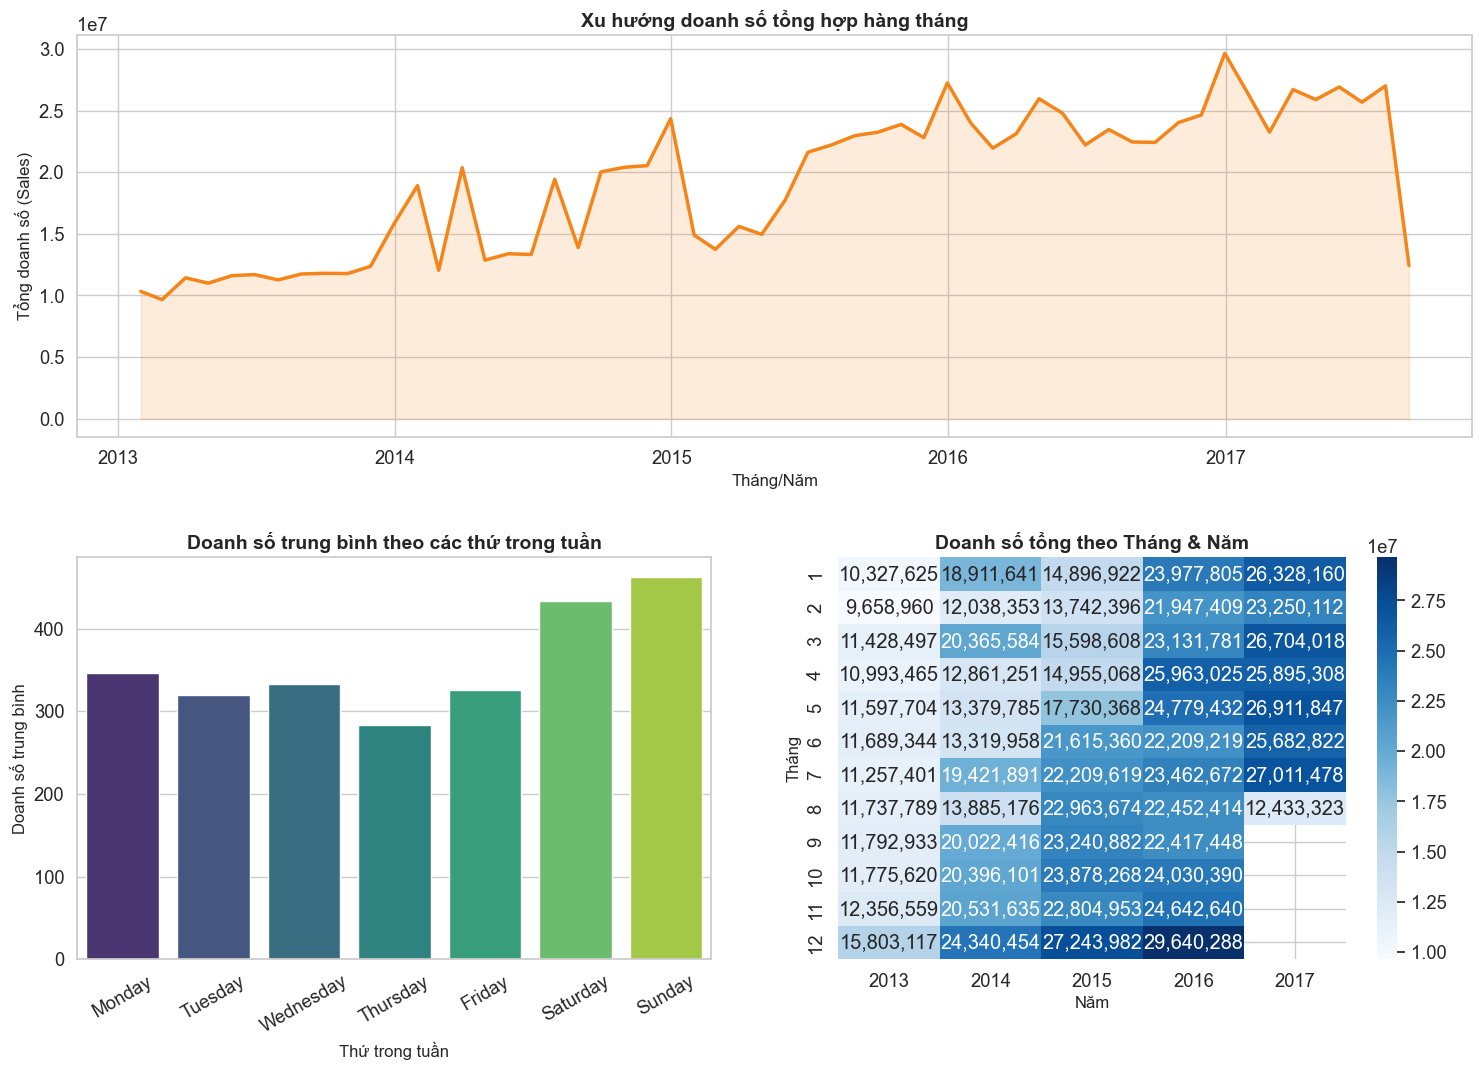

In [74]:
# 1. Doanh số hàng tháng
monthly_sales = train.groupby(pd.Grouper(key=DATE_COLUMN, freq="ME"))[TARGET].sum().reset_index()

# 2. Doanh số trung bình theo thứ tự các ngày trong tuần
train_copy = train.copy()
train_copy["day_of_week"] = train_copy[DATE_COLUMN].dt.dayofweek
train_copy["day_name"] = train_copy[DATE_COLUMN].dt.day_name()
days_order = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]
weekly_avg = train_copy.groupby("day_name")[TARGET].mean().reindex(days_order).reset_index()

# 3. Heatmap Month vs Year
train_copy["month"] = train_copy[DATE_COLUMN].dt.month
train_copy["year"] = train_copy[DATE_COLUMN].dt.year
month_year_sales = train_copy.pivot_table(
    values=TARGET, 
    index="month", 
    columns="year", 
    aggfunc="sum"
)

# Vẽ subplots
fig = plt.figure(figsize=(18, 12))
grid = plt.GridSpec(2, 2, wspace=0.2, hspace=0.3)

# Line chart Monthly Sales
ax_line = fig.add_subplot(grid[0, :])
ax_line.plot(monthly_sales[DATE_COLUMN], monthly_sales[TARGET], color=COLORS["secondary"], linewidth=2.5)
ax_line.fill_between(monthly_sales[DATE_COLUMN], monthly_sales[TARGET], color=COLORS["secondary"], alpha=0.15)
ax_line.set_title("Xu hướng doanh số tổng hợp hàng tháng")
ax_line.set_xlabel("Tháng/Năm")
ax_line.set_ylabel("Tổng doanh số (Sales)")

# Bar chart Day of Week
ax_bar = fig.add_subplot(grid[1, 0])
sns.barplot(data=weekly_avg, x="day_name", y=TARGET, ax=ax_bar, palette="viridis", hue="day_name", legend=False)
ax_bar.set_title("Doanh số trung bình theo các thứ trong tuần")
ax_bar.set_xlabel("Thứ trong tuần")
ax_bar.set_ylabel("Doanh số trung bình")
ax_bar.tick_params(axis="x", rotation=30)

# Heatmap Month vs Year
ax_heat = fig.add_subplot(grid[1, 1])
sns.heatmap(month_year_sales, annot=True, fmt=",.0f", cmap="Blues", ax=ax_heat)
ax_heat.set_title("Doanh số tổng theo Tháng & Năm")
ax_heat.set_xlabel("Năm")
ax_heat.set_ylabel("Tháng")

plt.show()


### 2.5 — Tác động của Khuyến mãi (Promotion)
Tìm hiểu xem việc chạy chương trình khuyến mãi có tác dụng nâng cao doanh số hay không và xu hướng chạy khuyến mãi của hệ thống cửa hàng theo thời gian.

Thống kê doanh số theo nhóm số lượng khuyến mãi:


,count,mean,median
promo_bucket,,,
0,2389559,158.2500,3.0000
1-5,355998,645.2600,211.3000
6-20,150471,"1,254.3600",487.8000
20+,104860,"2,642.0700","1,751.0000"


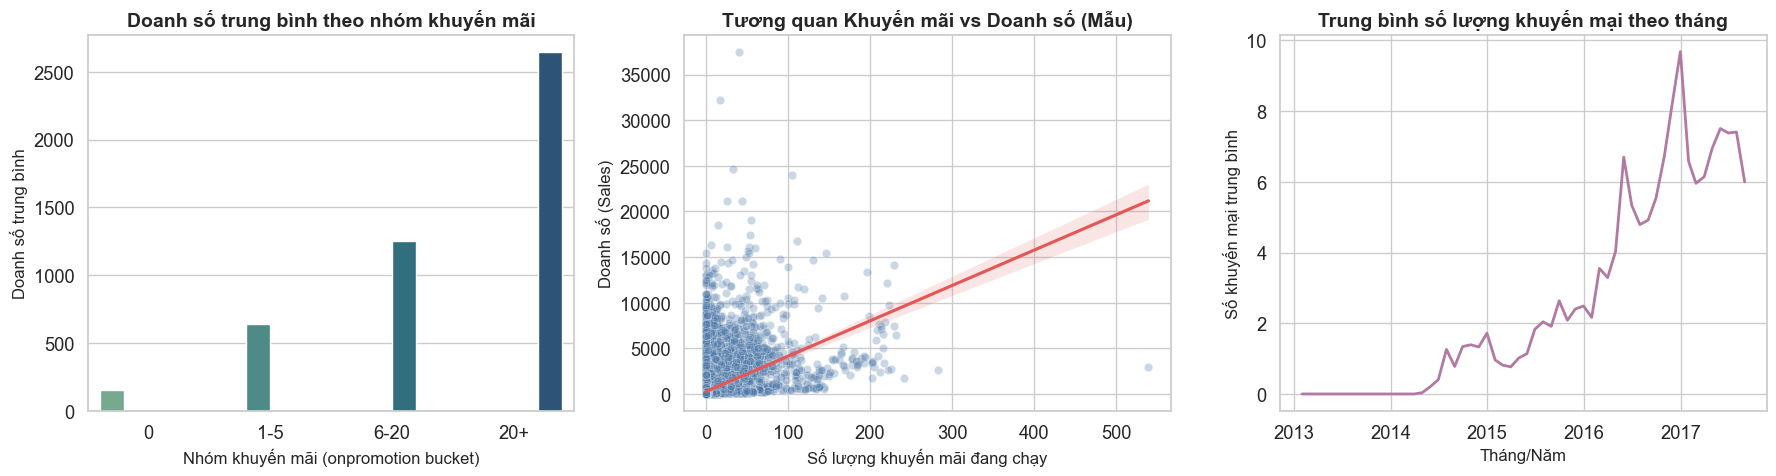

In [75]:
promo_eda = train.copy()
promo_eda["promo_bucket"] = pd.cut(
    promo_eda["onpromotion"],
    bins=[-1, 0, 5, 20, promo_eda["onpromotion"].max()],
    labels=["0", "1-5", "6-20", "20+"],
)
promo_summary = promo_eda.groupby("promo_bucket", observed=True)[TARGET].agg(["count", "mean", "median"]).round(2)
print("Thống kê doanh số theo nhóm số lượng khuyến mãi:")
display(promo_summary)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Bar chart trung bình sales theo bucket
sns.barplot(x=promo_summary.index, y=promo_summary["mean"], ax=axes[0], palette="crest", hue=promo_summary.index, legend=False)
axes[0].set_title("Doanh số trung bình theo nhóm khuyến mãi")
axes[0].set_xlabel("Nhóm khuyến mãi (onpromotion bucket)")
axes[0].set_ylabel("Doanh số trung bình")

# 2. Scatter plot onpromotion vs sales (lấy mẫu ngẫu nhiên)
sample_promo = train.sample(n=min(50_000, len(train)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample_promo, x="onpromotion", y=TARGET, alpha=0.3, ax=axes[1], color=COLORS["primary"])
sns.regplot(data=sample_promo, x="onpromotion", y=TARGET, scatter=False, ax=axes[1], color=COLORS["accent"])
axes[1].set_title("Tương quan Khuyến mãi vs Doanh số (Mẫu)")
axes[1].set_xlabel("Số lượng khuyến mãi đang chạy")
axes[1].set_ylabel("Doanh số (Sales)")

# 3. Tỷ lệ sản phẩm được khuyến mãi theo thời gian
promo_time = train.groupby(pd.Grouper(key=DATE_COLUMN, freq="ME"))["onpromotion"].mean().reset_index()
axes[2].plot(promo_time[DATE_COLUMN], promo_time["onpromotion"], color=COLORS["purple"], linewidth=2)
axes[2].set_title("Trung bình số lượng khuyến mại theo tháng")
axes[2].set_xlabel("Tháng/Năm")
axes[2].set_ylabel("Số khuyến mại trung bình")

plt.tight_layout()
plt.show()


### 2.6 — Phân tích đặc trưng Cửa hàng (Store Analysis)
Đánh giá xem doanh số có sự khác biệt lớn giữa các nhóm loại cửa hàng (`type`) và các cụm cửa hàng (`cluster`) hay không.

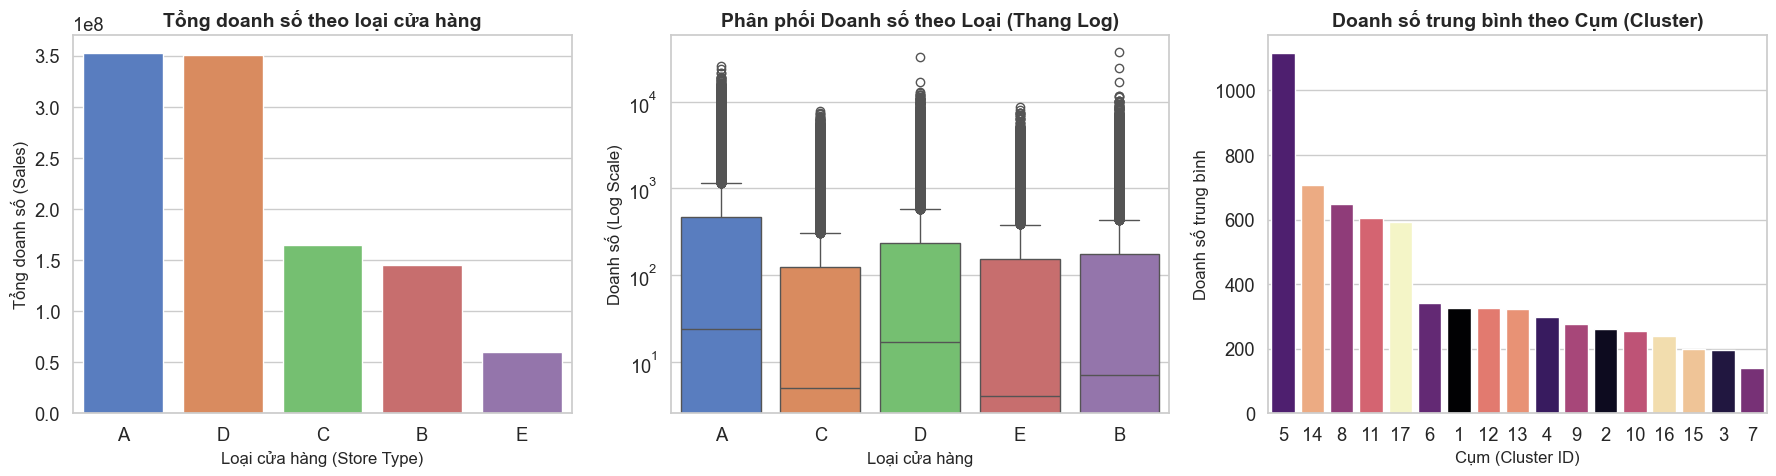

In [76]:
train_store = train.merge(stores, on="store_nbr", how="left")

fig, axes = plt.subplots(1, 3, figsize=(18, 5))

# 1. Tổng doanh số theo Loại cửa hàng
store_sales = train_store.groupby("type", observed=True)[TARGET].sum().sort_values(ascending=False).reset_index()
sns.barplot(data=store_sales, x="type", y=TARGET, ax=axes[0], palette="muted", hue="type", legend=False)
axes[0].set_title("Tổng doanh số theo loại cửa hàng")
axes[0].set_xlabel("Loại cửa hàng (Store Type)")
axes[0].set_ylabel("Tổng doanh số (Sales)")

# 2. Phân phối doanh số (Boxplot) theo loại cửa hàng (thang Log)
sample_store = train_store.sample(n=min(100_000, len(train_store)), random_state=RANDOM_STATE)
sns.boxplot(data=sample_store, x="type", y=TARGET, ax=axes[1], palette="muted", hue="type", legend=False)
axes[1].set_yscale("log")
axes[1].set_title("Phân phối Doanh số theo Loại (Thang Log)")
axes[1].set_xlabel("Loại cửa hàng")
axes[1].set_ylabel("Doanh số (Log Scale)")

# 3. Doanh số trung bình theo Cụm (Cluster)
cluster_sales = train_store.groupby("cluster", observed=True)[TARGET].mean().sort_values(ascending=False).reset_index()
sns.barplot(data=cluster_sales, x="cluster", y=TARGET, ax=axes[2], palette="magma", hue="cluster", order=cluster_sales["cluster"], legend=False)
axes[2].set_title("Doanh số trung bình theo Cụm (Cluster)")
axes[2].set_xlabel("Cụm (Cluster ID)")
axes[2].set_ylabel("Doanh số trung bình")

plt.tight_layout()
plt.show()


### 2.7 — Biến động Giá dầu & Yếu tố bên ngoài
Là một quốc gia xuất khẩu dầu mỏ, kinh tế Ecuador phụ thuộc nhiều vào giá dầu thô. Hãy cùng trực quan hóa mối tương quan giữa giá dầu (`dcoilwtico`) và tổng doanh số ngày toàn hệ thống.

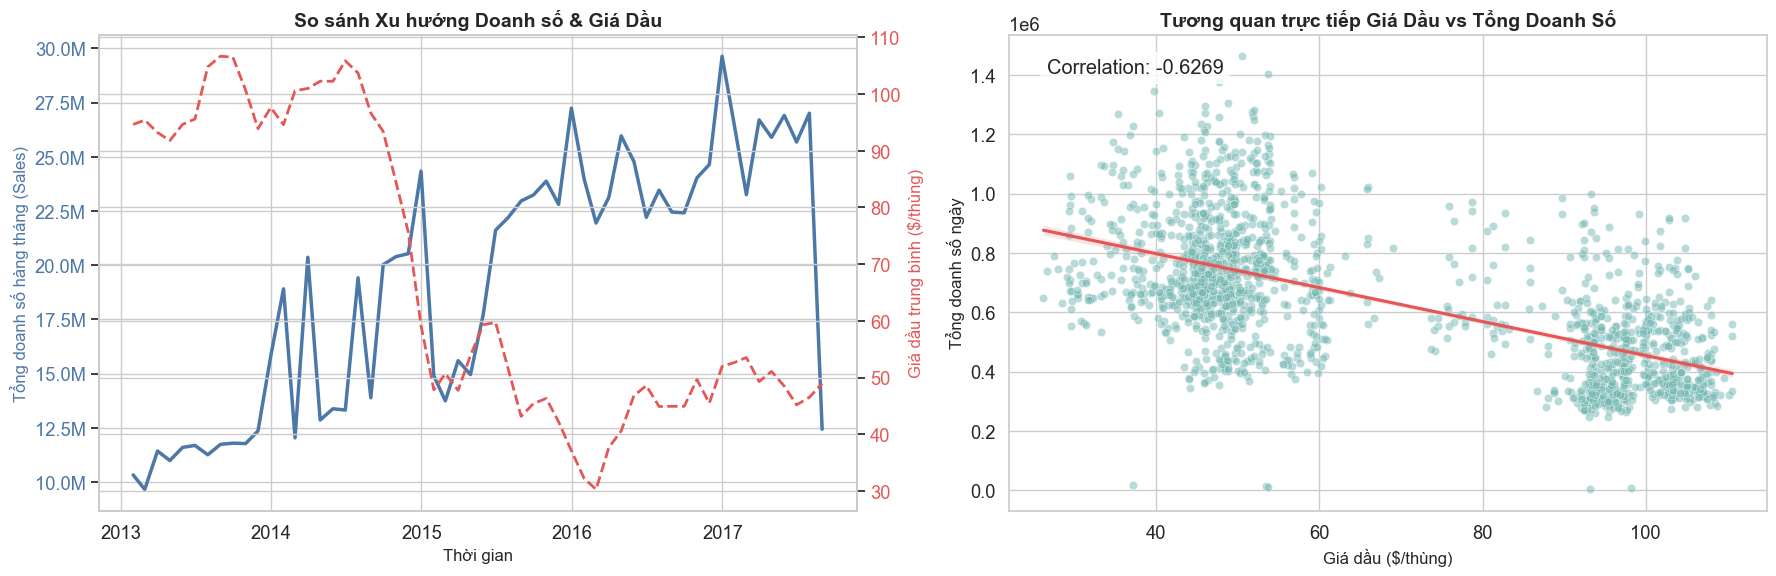

In [77]:
# Tính tổng sales hàng ngày toàn hệ thống
daily_sales = train.groupby(DATE_COLUMN)[TARGET].sum().reset_index()

# Điền khuyết thiếu cho giá dầu hàng ngày
oil_filled = oil.copy()
oil_filled["dcoilwtico"] = oil_filled["dcoilwtico"].ffill().bfill()

sales_oil = daily_sales.merge(oil_filled, on=DATE_COLUMN, how="left")
sales_oil["dcoilwtico"] = sales_oil["dcoilwtico"].ffill().bfill()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# 1. Đồ thị 2 trục y: Giá dầu vs Tổng doanh số hàng tháng
sales_oil_monthly = sales_oil.groupby(pd.Grouper(key=DATE_COLUMN, freq="ME")).agg(
    total_sales=(TARGET, "sum"),
    avg_oil=("dcoilwtico", "mean")
).reset_index()

ax1 = axes[0]
color = COLORS["primary"]
ax1.set_xlabel("Thời gian")
ax1.set_ylabel("Tổng doanh số hàng tháng (Sales)", color=color)
ax1.plot(sales_oil_monthly[DATE_COLUMN], sales_oil_monthly["total_sales"], color=color, linewidth=2.5, label="Sales")
ax1.tick_params(axis='y', labelcolor=color)
ax1.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x*1e-6:.1f}M'))

ax2 = ax1.twinx()  
color = COLORS["accent"]
ax2.set_ylabel("Giá dầu trung bình ($/thùng)", color=color)
ax2.plot(sales_oil_monthly[DATE_COLUMN], sales_oil_monthly["avg_oil"], color=color, linewidth=2, linestyle="--", label="Giá dầu")
ax2.tick_params(axis='y', labelcolor=color)

axes[0].set_title("So sánh Xu hướng Doanh số & Giá Dầu")

# 2. Scatter plot Giá dầu vs Doanh số hàng ngày + Correlation
sns.scatterplot(data=sales_oil, x="dcoilwtico", y=TARGET, alpha=0.5, ax=axes[1], color=COLORS["teal"])
sns.regplot(data=sales_oil, x="dcoilwtico", y=TARGET, scatter=False, ax=axes[1], color=COLORS["accent"])
axes[1].set_title("Tương quan trực tiếp Giá Dầu vs Tổng Doanh Số")
axes[1].set_xlabel("Giá dầu ($/thùng)")
axes[1].set_ylabel("Tổng doanh số ngày")

corr_coef = sales_oil[TARGET].corr(sales_oil["dcoilwtico"])
axes[1].text(0.05, 0.95, f"Correlation: {corr_coef:.4f}", transform=axes[1].transAxes, 
             verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.tight_layout()
plt.show()


### 2.8 — Tác động của Ngày lễ (Holidays) & Lượng Giao dịch (Transactions)
Khám phá các loại ngày lễ trong tập dữ liệu, sự khác biệt về doanh số ngày lễ quốc gia so với ngày thường và mối liên kết trực tiếp giữa số lượng giao dịch ngân hàng (`transactions`) với doanh số bán hàng.

Top 5 ngày có doanh số toàn hệ thống cao nhất:


,date,sales,day_name,is_holiday
1547,2017-04-01,"1,463,083.9625",Saturday,No
1458,2017-01-02,"1,402,306.3708",Monday,Yes
1611,2017-06-04,"1,376,511.5205",Sunday,No
1200,2016-04-18,"1,345,920.6049",Monday,Yes
1577,2017-05-01,"1,306,699.3669",Monday,Yes


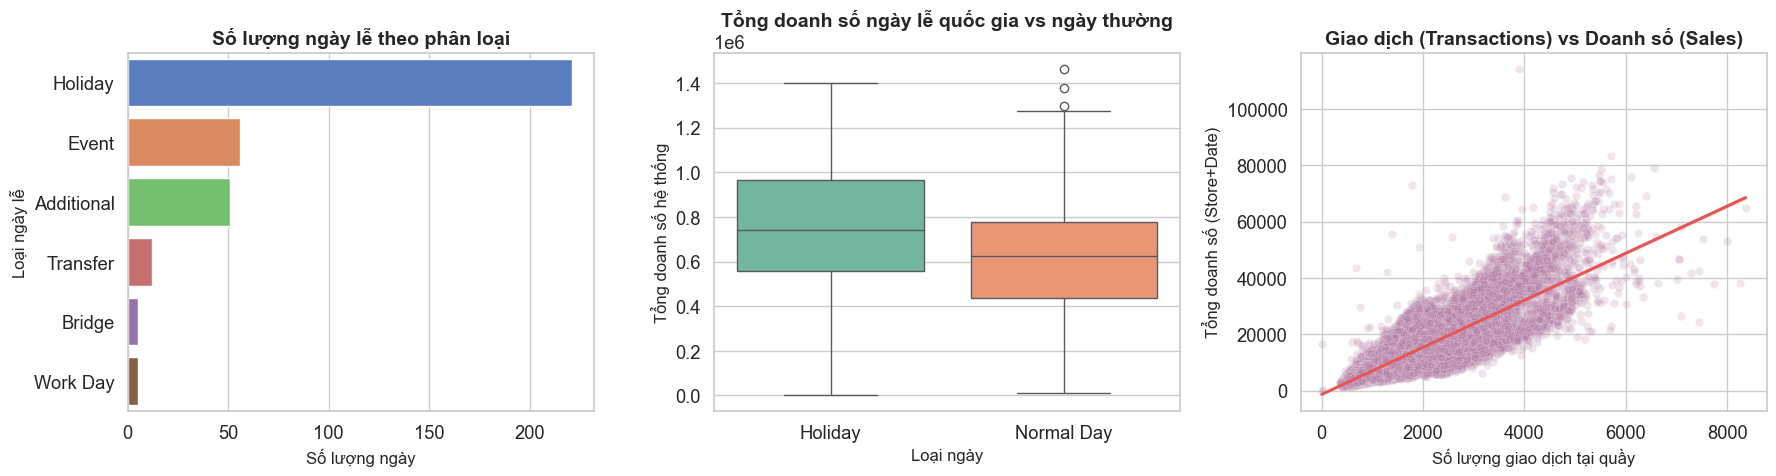

In [78]:
# 1. Bar chart số lượng ngày lễ theo type
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

holiday_types = holidays["type"].value_counts().reset_index()
sns.barplot(data=holiday_types, x="count", y="type", ax=axes[0], palette="muted", hue="type", legend=False)
axes[0].set_title("Số lượng ngày lễ theo phân loại")
axes[0].set_xlabel("Số lượng ngày")
axes[0].set_ylabel("Loại ngày lễ")

# 2. Phân biệt ngày lễ quốc gia vs ngày thường
national_holidays = holidays[(holidays["locale"] == "National") & (holidays["transferred"] == False)]
holiday_dates = set(national_holidays[DATE_COLUMN].dt.date)

daily_sales_holiday = daily_sales.copy()
daily_sales_holiday["is_holiday"] = daily_sales_holiday[DATE_COLUMN].dt.date.apply(lambda d: "Holiday" if d in holiday_dates else "Normal Day")

sns.boxplot(data=daily_sales_holiday, x="is_holiday", y=TARGET, ax=axes[1], palette="Set2", hue="is_holiday", legend=False)
axes[1].set_title("Tổng doanh số ngày lễ quốc gia vs ngày thường")
axes[1].set_xlabel("Loại ngày")
axes[1].set_ylabel("Tổng doanh số hệ thống")

# 3. Tương quan giữa Transactions và Sales
daily_trans = transactions.groupby([DATE_COLUMN, "store_nbr"])["transactions"].sum().reset_index()
train_trans = train.groupby([DATE_COLUMN, "store_nbr"])[TARGET].sum().reset_index()

trans_sales = train_trans.merge(daily_trans, on=[DATE_COLUMN, "store_nbr"], how="inner")

# Vẽ mẫu scatter plot
sample_trans = trans_sales.sample(n=min(30_000, len(trans_sales)), random_state=RANDOM_STATE)
sns.scatterplot(data=sample_trans, x="transactions", y=TARGET, alpha=0.2, ax=axes[2], color=COLORS["purple"])
sns.regplot(data=sample_trans, x="transactions", y=TARGET, scatter=False, ax=axes[2], color=COLORS["accent"])
axes[2].set_title("Giao dịch (Transactions) vs Doanh số (Sales)")
axes[2].set_xlabel("Số lượng giao dịch tại quầy")
axes[2].set_ylabel("Tổng doanh số (Store+Date)")

# In ra top 5 ngày có doanh số cao nhất hệ thống
top_sales_days = daily_sales.sort_values(by=TARGET, ascending=False).head(5).copy()
top_sales_days["day_name"] = top_sales_days[DATE_COLUMN].dt.day_name()
top_sales_days["is_holiday"] = top_sales_days[DATE_COLUMN].dt.date.apply(lambda d: "Yes" if d in holiday_dates else "No")

print("Top 5 ngày có doanh số toàn hệ thống cao nhất:")
display(top_sales_days)

plt.tight_layout()
plt.show()


## Bước 2.5: Xử lý dữ liệu & Chuẩn bị đặc trưng

Trong bước này, chúng ta tiến hành:
- Kiểm tra các dữ liệu trùng lặp (duplicate data) trên tất cả các bảng dữ liệu.
- Xử lý các giá trị khuyết thiếu (missing data) được phát hiện trong EDA.
- Cân nhắc chiến lược chuẩn hóa đặc trưng (standardization/scaling) cho các mô hình máy học khác nhau.

In [79]:
# 1. Kiểm tra dữ liệu trùng lặp (Duplicate Data)
datasets = {
    "train": train,
    "test": test,
    "stores": stores,
    "oil": oil,
    "holidays": holidays,
    "transactions": transactions
}

print("📊 SỐ LƯỢNG DÒNG TRÙNG LẶP TRONG CÁC DATASET:")
for name, df in datasets.items():
    dup_count = df.duplicated().sum()
    print(f"  - Bảng '{name}': {dup_count} dòng trùng lặp")

# 2. Xử lý giá trị khuyết thiếu (Missing Data)
# Trong EDA bước 2.1, chúng ta phát hiện bảng 'oil' bị thiếu 43 giá trị dcoilwtico (giá dầu).
# Việc xử lý sẽ được tích hợp trực tiếp bằng phương pháp ffill() và bfill() trong hàm build_feature_frame ở bước sau.
# Điều này đảm bảo giá dầu luôn liên tục theo dòng thời gian mà không bị ngắt quãng.

📊 SỐ LƯỢNG DÒNG TRÙNG LẶP TRONG CÁC DATASET:
  - Bảng 'train': 0 dòng trùng lặp
  - Bảng 'test': 0 dòng trùng lặp
  - Bảng 'stores': 0 dòng trùng lặp
  - Bảng 'oil': 0 dòng trùng lặp
  - Bảng 'holidays': 0 dòng trùng lặp
  - Bảng 'transactions': 0 dòng trùng lặp


### 2.5.1 — Cân nhắc chuẩn hóa đặc trưng (Feature Standardization)

- **Các mô hình tuyến tính (Ridge) và Mạng nơ-ron (MLP)**: Nhạy cảm với tỷ lệ/phạm vi của các đặc trưng số. Nếu các đặc trưng có giá trị quá lớn hoặc quá nhỏ lệch nhau (như giá dầu so với số ngày khuyến mãi), mô hình sẽ hội tụ chậm hoặc không chính xác. Do đó, chúng ta **cần chuẩn hóa** các đặc trưng này về dạng phân phối chuẩn ($mean=0, std=1$) bằng `StandardScaler`.
- **Các mô hình dạng cây quyết định (HistGradientBoosting)**: Hoàn toàn bất biến với tỷ lệ của đặc trưng (scale-invariant), do việc phân chia tại mỗi nút cây chỉ phụ thuộc vào thứ tự lớn bé của giá trị. Vì vậy, đối với HistGradientBoosting, chúng ta **không cần chuẩn hóa đặc trưng**.

Các chiến lược này được hiện thực hóa trong các pipelines tiền xử lý tương ứng (`make_one_hot_preprocessor` và `make_ordinal_preprocessor`) ở Bước 5.

## Bước 3. Tạo đặc trưng

Các nhóm đặc trưng được tạo:

- Đặc trưng lịch: `dayofweek`, `month`, `year`, `dayofmonth`, `is_weekend`.
- Đặc trưng cửa hàng: `city`, `state`, `type`, `cluster`.
- Tín hiệu bên ngoài: giá dầu và holiday/event flags.
- Đặc trưng time-series: `lag_16`, `lag_28`, `lag_364`, rolling mean dịch 16 ngày.

Dịch 16 ngày giúp mô phỏng đúng bài toán dự đoán 16 ngày tương lai mà không nhìn vào doanh số của chính giai đoạn validation/test.

In [80]:
def make_holiday_daily(holidays_df: pd.DataFrame) -> pd.DataFrame:
    active = holidays_df[~holidays_df["transferred"]].copy()
    return (
        active.groupby(DATE_COLUMN)
        .agg(
            is_holiday=("type", lambda values: int((values != "Work Day").any())),
            holiday_count=("type", "size"),
        )
        .reset_index()
    )


def add_calendar_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.copy()
    out["dayofweek"] = out[DATE_COLUMN].dt.dayofweek
    out["month"] = out[DATE_COLUMN].dt.month
    out["year"] = out[DATE_COLUMN].dt.year
    out["dayofmonth"] = out[DATE_COLUMN].dt.day
    out["is_weekend"] = out["dayofweek"].isin([5, 6]).astype(int)
    return out


def add_lag_features(frame: pd.DataFrame) -> pd.DataFrame:
    out = frame.sort_values(["store_nbr", "family", DATE_COLUMN]).copy()
    grouped_sales = out.groupby(["store_nbr", "family"])[TARGET]
    for lag in [16, 28, 364]:
        out[f"lag_{lag}"] = grouped_sales.shift(lag)
    out["rolling_mean_7_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(7, min_periods=1).mean()
    )
    out["rolling_mean_28_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(28, min_periods=1).mean()
    )
    out["rolling_mean_56_shift16"] = grouped_sales.transform(
        lambda sales: sales.shift(16).rolling(56, min_periods=1).mean()
    )
    return out


def build_feature_frame(sales_frame: pd.DataFrame) -> pd.DataFrame:
    oil_clean = oil.sort_values(DATE_COLUMN).copy()
    oil_clean["dcoilwtico"] = oil_clean["dcoilwtico"].ffill().bfill()
    holiday_daily = make_holiday_daily(holidays)

    out = (
        sales_frame.merge(stores, on="store_nbr", how="left")
        .merge(oil_clean, on=DATE_COLUMN, how="left")
        .merge(holiday_daily, on=DATE_COLUMN, how="left")
    )
    out[["is_holiday", "holiday_count"]] = out[["is_holiday", "holiday_count"]].fillna(0)
    out["dcoilwtico"] = out["dcoilwtico"].ffill().bfill()
    out = add_calendar_features(out)
    out = add_lag_features(out)

    lag_columns = [
        "lag_16",
        "lag_28",
        "lag_364",
        "rolling_mean_7_shift16",
        "rolling_mean_28_shift16",
        "rolling_mean_56_shift16",
    ]
    out[lag_columns] = out[lag_columns].fillna(0)
    return out

## Bước 4. Tạo tập train/validation theo thời gian

Validation dùng 16 ngày cuối của `train.csv`, tương ứng đúng forecast horizon trong `test.csv`. Notebook chỉ dùng 365 ngày gần nhất để train nhằm giảm thời gian chạy và ưu tiên tín hiệu gần hiện tại.

In [81]:
feature_frame = build_feature_frame(train)
validation_start = feature_frame[DATE_COLUMN].max() - pd.Timedelta(days=VALIDATION_DAYS - 1)
fit_start = validation_start - pd.Timedelta(days=RECENT_TRAIN_DAYS)

fit_df = feature_frame[
    (feature_frame[DATE_COLUMN] < validation_start)
    & (feature_frame[DATE_COLUMN] >= fit_start)
].copy()
valid_df = feature_frame[feature_frame[DATE_COLUMN] >= validation_start].copy()

print("fit:", fit_df.shape, fit_df[DATE_COLUMN].min().date(), fit_df[DATE_COLUMN].max().date())
print("valid:", valid_df.shape, valid_df[DATE_COLUMN].min().date(), valid_df[DATE_COLUMN].max().date())

fit: (648648, 24) 2016-07-31 2017-07-30
valid: (28512, 24) 2017-07-31 2017-08-15


### 3.1 — Ma trận tương quan giữa các đặc trưng (Correlation Matrix)
Chúng ta vẽ ma trận tương quan giữa biến mục tiêu `sales` và các đặc trưng số để xem các đặc trưng nào có tương quan tuyến tính mạnh nhất với doanh số.

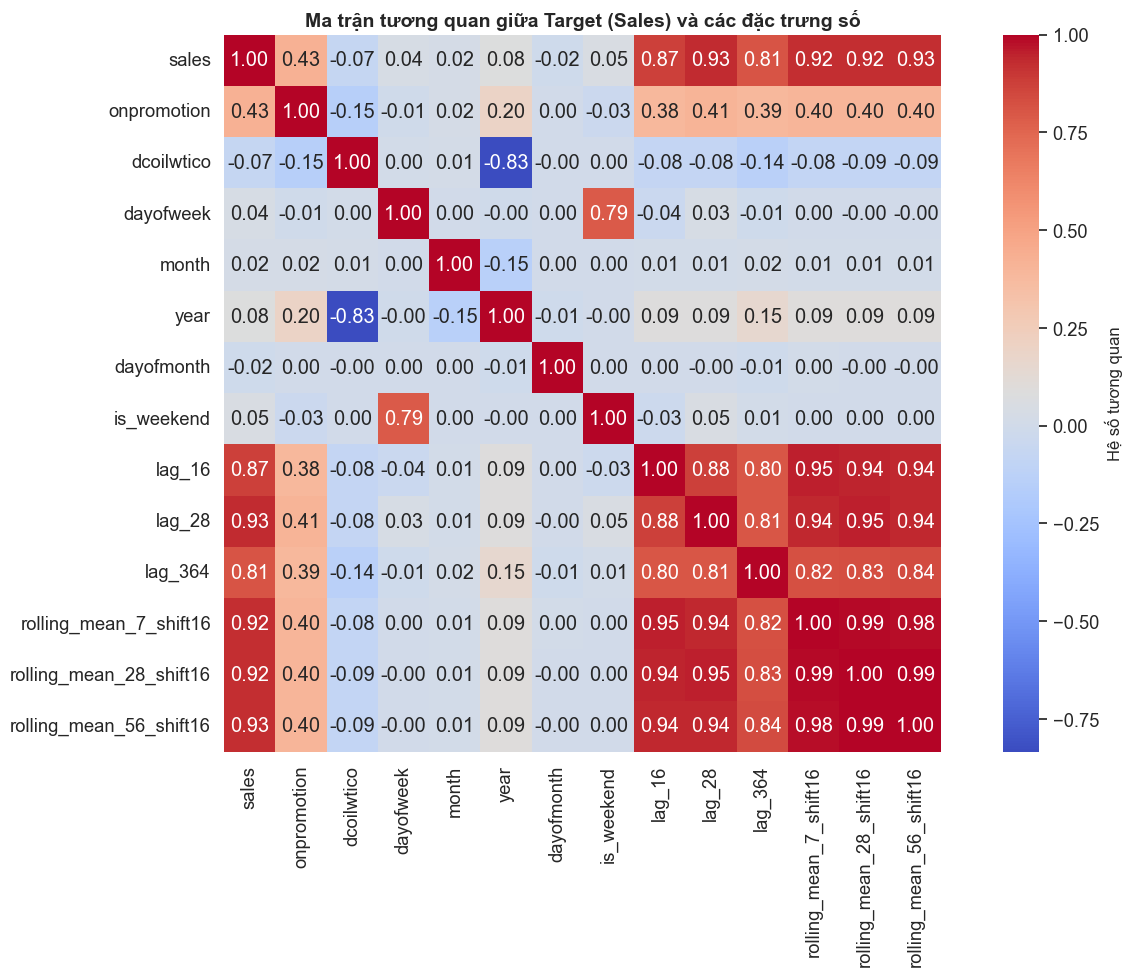

In [82]:
# Tính toán ma trận tương quan của các đặc trưng số và Target
numeric_cols = ["sales", "onpromotion", "dcoilwtico", "dayofweek", "month", "year", "dayofmonth", "is_weekend"]
# Thêm các đặc trưng lag/rolling nếu tồn tại
lag_cols = [c for c in ["lag_16", "lag_28", "lag_364", "rolling_mean_7_shift16", "rolling_mean_28_shift16", "rolling_mean_56_shift16"] if c in feature_frame.columns]
cols_to_corr = numeric_cols + lag_cols

sample_df = feature_frame[cols_to_corr].sample(n=min(100_000, len(feature_frame)), random_state=RANDOM_STATE)
corr_matrix = sample_df.corr()

plt.figure(figsize=(14, 10))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", square=True, cbar_kws={"label": "Hệ số tương quan"})
plt.title("Ma trận tương quan giữa Target (Sales) và các đặc trưng số")
plt.tight_layout()
plt.show()


## Bước 5. Metric và tiền xử lý

RMSLE được chọn vì `sales` không âm và lệch phải. Model được train trên `log1p(sales)`, sau đó chuyển ngược bằng `expm1` để đánh giá trên thang sales gốc.

In [83]:
NUMERIC_FEATURES = [
    "onpromotion",
    "dcoilwtico",
    "dayofweek",
    "month",
    "year",
    "dayofmonth",
    "is_weekend",
    "is_holiday",
    "holiday_count",
    "lag_16",
    "lag_28",
    "lag_364",
    "rolling_mean_7_shift16",
    "rolling_mean_28_shift16",
    "rolling_mean_56_shift16",
]
CATEGORICAL_FEATURES = ["store_nbr", "family", "city", "state", "type", "cluster"]
FEATURE_COLUMNS = NUMERIC_FEATURES + CATEGORICAL_FEATURES


def rmsle(y_true: pd.Series | np.ndarray, y_pred: np.ndarray) -> float:
    clipped = np.clip(y_pred, 0, None)
    return float(np.sqrt(mean_squared_error(np.log1p(y_true), np.log1p(clipped))))


def sales_metrics(y_true: pd.Series, y_pred: np.ndarray) -> dict[str, float]:
    clipped = np.clip(y_pred, 0, None)
    return {
        "RMSLE": rmsle(y_true, clipped),
        "MAE": float(mean_absolute_error(y_true, clipped)),
        "RMSE": float(np.sqrt(mean_squared_error(y_true, clipped))),
        "R2": float(r2_score(y_true, clipped)),
    }


def make_one_hot_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(
        steps=[("imputer", SimpleImputer(strategy="median")), ("scaler", StandardScaler())]
    )
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            ("onehot", OneHotEncoder(handle_unknown="ignore", sparse_output=True)),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )


def make_ordinal_preprocessor() -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

### 5.1 — Danh sách đặc trưng và Kích thước dữ liệu đầu vào
Hãy cùng tổng kết lại danh sách các đặc trưng số (numerical features), đặc trưng phân loại (categorical features), biến mục tiêu (target) và kích thước (shape) cụ thể của các tập dữ liệu huấn luyện (Fit) và kiểm thử (Validation).

In [84]:
print(f"🎯 BIẾN MỤC TIÊU (TARGET COLUMN): '{TARGET}' (Kiểu dữ liệu: {fit_df[TARGET].dtype})")
print("\n🔢 ĐẶC TRƯNG SỐ (NUMERICAL FEATURES) - Số lượng:", len(NUMERIC_FEATURES))
for idx, col in enumerate(NUMERIC_FEATURES, 1):
    print(f"  {idx}. {col} ({fit_df[col].dtype})")

print("\n🔠 ĐẶC TRƯNG PHÂN LOẠI (CATEGORICAL FEATURES) - Số lượng:", len(CATEGORICAL_FEATURES))
for idx, col in enumerate(CATEGORICAL_FEATURES, 1):
    print(f"  {idx}. {col} ({fit_df[col].dtype})")

print(f"\n📊 KÍCH THƯỚC DỮ LIỆU ĐẦU VÀO (DATA DIMENSIONS):")
print(f"  - Tập Huấn luyện (Fit): Features {fit_df[FEATURE_COLUMNS].shape} | Target {fit_df[TARGET].shape}")
print(f"  - Tập Kiểm thử (Validation): Features {valid_df[FEATURE_COLUMNS].shape} | Target {valid_df[TARGET].shape}")


🎯 BIẾN MỤC TIÊU (TARGET COLUMN): 'sales' (Kiểu dữ liệu: float64)

🔢 ĐẶC TRƯNG SỐ (NUMERICAL FEATURES) - Số lượng: 15
  1. onpromotion (int64)
  2. dcoilwtico (float64)
  3. dayofweek (int32)
  4. month (int32)
  5. year (int32)
  6. dayofmonth (int32)
  7. is_weekend (int64)
  8. is_holiday (float64)
  9. holiday_count (float64)
  10. lag_16 (float64)
  11. lag_28 (float64)
  12. lag_364 (float64)
  13. rolling_mean_7_shift16 (float64)
  14. rolling_mean_28_shift16 (float64)
  15. rolling_mean_56_shift16 (float64)

🔠 ĐẶC TRƯNG PHÂN LOẠI (CATEGORICAL FEATURES) - Số lượng: 6
  1. store_nbr (int64)
  2. family (str)
  3. city (str)
  4. state (str)
  5. type (str)
  6. cluster (int64)

📊 KÍCH THƯỚC DỮ LIỆU ĐẦU VÀO (DATA DIMENSIONS):
  - Tập Huấn luyện (Fit): Features (648648, 21) | Target (648648,)
  - Tập Kiểm thử (Validation): Features (28512, 21) | Target (28512,)


## Bước 6. Baseline time-series

### 6.1 — Định nghĩa và vai trò của Baseline trong Time-series Forecasting

Trong các bài toán dự báo chuỗi thời gian (time-series forecasting), mô hình **Baseline** (đường cơ sở) đóng vai trò vô cùng quan trọng:
- **Benchmark cốt lõi**: Baseline là các mô hình đơn giản, dựa trên các heuristic hoặc quy tắc cố định (ví dụ: dùng lại giá trị của quá khứ làm dự báo tương lai) mà không đòi hỏi huấn luyện phức tạp.
- **Thước đo giá trị**: Một mô hình máy học (ML) phức tạp chỉ thực sự có giá trị thực tế nếu nó mang lại hiệu năng (độ lỗi thấp hơn, ví dụ RMSLE nhỏ hơn) vượt trội hơn so với các mô hình baseline đơn giản này. Nếu không, việc triển khai mô hình ML là vô nghĩa vì tốn nhiều tài nguyên hơn mà hiệu quả kém hơn.

### 6.2 — Các mô hình Baseline được lựa chọn

Trong notebook này, chúng ta sử dụng 4 mô hình baseline sau để so sánh:
1. **Lag_16**: Dự đoán doanh số của ngày hôm nay bằng đúng doanh số của 16 ngày trước (đây là khoảng thời gian dự báo tối thiểu cần thiết để tránh rò rỉ thông tin trong tập validation/test có độ dài 16 ngày).
2. **Lag_28**: Dự đoán doanh số bằng doanh số của 28 ngày trước (tương ứng chu kỳ đúng 4 tuần trước).
3. **Rolling_Mean_28_Shift16**: Dự đoán doanh số bằng trung bình trượt của 28 ngày trước đó, dịch chuyển đi 16 ngày.
4. **Rolling_Mean_56_Shift16**: Dự đoán doanh số bằng trung bình trượt của 56 ngày trước đó, dịch chuyển đi 16 ngày.

Nếu mô hình Machine Learning ở bước tiếp theo không vượt qua được mức RMSLE của các baseline này, chúng ta cần xem xét lại cấu trúc mô hình hoặc cách trích xuất đặc trưng.

In [85]:
baseline_rows = []
for baseline_name, column in {
    "Lag_16": "lag_16",
    "Lag_28": "lag_28",
    "Rolling_Mean_28_Shift16": "rolling_mean_28_shift16",
    "Rolling_Mean_56_Shift16": "rolling_mean_56_shift16",
}.items():
    baseline_rows.append({"model": baseline_name, **sales_metrics(valid_df[TARGET], valid_df[column].to_numpy())})

baseline_df = pd.DataFrame(baseline_rows).sort_values("RMSLE")
display(baseline_df)

,model,RMSLE,MAE,RMSE,R2
3,Rolling_Mean_56_Shift16,0.5457,100.7703,328.1033,0.9309
2,Rolling_Mean_28_Shift16,0.5502,99.0406,322.1254,0.9334
1,Lag_28,0.6274,82.8711,311.2467,0.9378
0,Lag_16,0.6967,145.2255,510.0780,0.8330


## Bước 7. Huấn luyện và đánh giá mô hình

Các mô hình được so sánh:

- Ridge regression trên one-hot features.
- Mạng nơ-ron 1 lớp (Inputs -> Output) tự code từ đầu vs SGDRegressor (Sklearn) để double check.
- Mạng nơ-ron có 1 lớp ẩn (1 hidden layer) tự code từ đầu vs MLPRegressor (Sklearn) để double check.
- HistGradientBoosting trên ordinal-encoded categorical features.

Mục tiêu là chọn mô hình có RMSLE thấp nhất trên validation 16 ngày cuối.

In [86]:
x_fit = fit_df[FEATURE_COLUMNS]
y_fit_log = np.log1p(fit_df[TARGET])
x_valid = valid_df[FEATURE_COLUMNS]
y_valid = valid_df[TARGET]

# Import các mô hình tự triển khai từ model.py
from lab02.model import RidgeRegressionScratch, MLPRegressorScratch, HistGradientBoostingRegressorScratch

models = {
    "Ridge_Scratch": Pipeline(
        steps=[("preprocess", make_one_hot_preprocessor()), ("model", RidgeRegressionScratch(alpha=10.0))]
    ),
    "MLP_Scratch": Pipeline(
        steps=[
            ("preprocess", make_one_hot_preprocessor()),
            ("model", MLPRegressorScratch(hidden_dim=16, lr=0.01, epochs=20, batch_size=1024, random_state=RANDOM_STATE))
        ]
    ),
    "HistGradientBoosting_Scratch_160": Pipeline(
        steps=[
            ("preprocess", make_ordinal_preprocessor()),
            ("model", HistGradientBoostingRegressorScratch(max_iter=160, learning_rate=0.04, random_state=RANDOM_STATE))
        ]
    )
}

model_rows = []
fitted_models: dict[str, Pipeline] = {}
predictions: dict[str, np.ndarray] = {}

for model_name, pipeline in models.items():
    print(f"Training {model_name}...")
    pipeline.fit(x_fit, y_fit_log)
    pred = np.clip(np.expm1(pipeline.predict(x_valid)), 0, None)
    model_rows.append({"model": model_name, **sales_metrics(y_valid, pred)})
    fitted_models[model_name] = pipeline
    predictions[model_name] = pred

model_df = pd.DataFrame(model_rows).sort_values("RMSLE")

# ── Double Check: Đánh giá độ lệch MAE giữa Scratch và Sklearn ──
print('\n--- Double Check: Scratch vs Sklearn MAE comparison ---')
from lab02.model import ModelDoubleChecker
preproc = make_one_hot_preprocessor()
X_fit_prep = preproc.fit_transform(x_fit, y_fit_log)
X_valid_prep = preproc.transform(x_valid)
checker = ModelDoubleChecker(random_state=RANDOM_STATE)
check_results = checker.check_models(X_fit_prep, y_fit_log, X_valid_prep, y_valid)
display(check_results)

# ── So sánh hiệu năng giữa Baselines và các mô hình Scratch ──
print('\n--- Final Comparison: Baselines vs Scratch ML Models ---')
comparison_df = pd.concat([baseline_df, model_df], ignore_index=True).sort_values("RMSLE")
display(comparison_df)

best_row = model_df.sort_values("RMSLE").iloc[0].to_dict()
best_model_name = best_row["model"]
best_model = fitted_models[best_model_name]
best_valid_pred = predictions[best_model_name]

print("\nSelected model:", best_model_name)
print(json.dumps({k: round(v, 4) if isinstance(v, float) else v for k, v in best_row.items()}, indent=2))


Training Ridge_Scratch...
Training MLP_Scratch...
Training HistGradientBoosting_Scratch_160...

--- Double Check: Scratch vs Sklearn MAE comparison ---


/Users/quangmanh/Project/lab02/.venv/lib/python3.12/site-packages/sklearn/neural_network/_multilayer_perceptron.py:785: ConvergenceWarning: Stochastic Optimizer: Maximum iterations (10) reached and the optimization hasn't converged yet.
  warnings.warn(


,Scratch_MAE,Sklearn_MAE,Absolute_Diff
Ridge,463.7167,463.7184,0.0017
MLP,463.6880,463.5659,0.1222
HistGradientBoosting,463.6848,463.6837,0.0011



--- Final Comparison: Baselines vs Scratch ML Models ---


,model,RMSLE,MAE,RMSE,R2
4,HistGradientBoosting_Scratch_160,0.4644,90.5285,365.3726,0.9143
0,Rolling_Mean_56_Shift16,0.5457,100.7703,328.1033,0.9309
1,Rolling_Mean_28_Shift16,0.5502,99.0406,322.1254,0.9334
5,MLP_Scratch,0.6043,131.1944,695.7009,0.6894
2,Lag_28,0.6274,82.8711,311.2467,0.9378
3,Lag_16,0.6967,145.2255,510.0780,0.8330
6,Ridge_Scratch,0.7990,217.2297,"1,357.7573",-0.1829



Selected model: HistGradientBoosting_Scratch_160
{
  "model": "HistGradientBoosting_Scratch_160",
  "RMSLE": 0.4644,
  "MAE": 90.5285,
  "RMSE": 365.3726,
  "R2": 0.9143
}


### 7.1 — Cải tiến 1: Huấn luyện HistGradientBoosting_Scratch trực tiếp trên target gốc (không qua log)

Để tối ưu hóa các chỉ số tuyệt đối như MAE, RMSE và R2, chúng ta huấn luyện mô hình trực tiếp trên doanh số thực tế `sales` thay vì log-transform.

In [87]:
# Huấn luyện HistGradientBoosting_Scratch trực tiếp trên target gốc
print("Training HistGradientBoosting_Scratch on raw target...")
hgb_raw_pipeline = Pipeline(
    steps=[
        ("preprocess", make_ordinal_preprocessor()),
        ("model", HistGradientBoostingRegressorScratch(max_iter=160, learning_rate=0.04, random_state=RANDOM_STATE))
    ]
)
hgb_raw_pipeline.fit(x_fit, fit_df[TARGET])
pred_raw = np.clip(hgb_raw_pipeline.predict(x_valid), 0, None)

hgb_raw_metrics = sales_metrics(y_valid, pred_raw)
print("HistGradientBoosting_Scratch (Raw Target) Metrics:")
display(hgb_raw_metrics)

Training HistGradientBoosting_Scratch on raw target...
HistGradientBoosting_Scratch (Raw Target) Metrics:


{'RMSLE': 0.9958719797283729,
 'MAE': 76.39170186078498,
 'RMSE': 260.2313021978885,
 'R2': 0.9565456167505704}

### 7.2 — Cải tiến 2: Tạo đặc trưng tương tác phi tuyến (Interaction Features)

Chúng ta tạo các đặc trưng tương tác nhân chéo như `onpromotion * lag_28` và `is_weekend * lag_28` để giúp mô hình cây học nhanh hơn mối liên hệ phi tuyến.

In [88]:
# Tạo đặc trưng tương tác nhân chéo
x_fit_inter = x_fit.copy()
x_valid_inter = x_valid.copy()

x_fit_inter["onpromotion_x_lag_28"] = x_fit_inter["onpromotion"] * x_fit_inter["lag_28"]
x_fit_inter["is_weekend_x_lag_28"] = x_fit_inter["is_weekend"] * x_fit_inter["lag_28"]

x_valid_inter["onpromotion_x_lag_28"] = x_valid_inter["onpromotion"] * x_valid_inter["lag_28"]
x_valid_inter["is_weekend_x_lag_28"] = x_valid_inter["is_weekend"] * x_valid_inter["lag_28"]

# Cập nhật preprocessor cho các đặc trưng mới
NUMERIC_FEATURES_INTER = NUMERIC_FEATURES + ["onpromotion_x_lag_28", "is_weekend_x_lag_28"]

def make_ordinal_preprocessor_inter() -> ColumnTransformer:
    numeric_pipeline = Pipeline(steps=[("imputer", SimpleImputer(strategy="median"))])
    categorical_pipeline = Pipeline(
        steps=[
            ("imputer", SimpleImputer(strategy="most_frequent")),
            (
                "ordinal",
                OrdinalEncoder(
                    handle_unknown="use_encoded_value",
                    unknown_value=-1,
                    encoded_missing_value=-1,
                    
                ),
            ),
        ]
    )
    return ColumnTransformer(
        transformers=[
            ("numeric", numeric_pipeline, NUMERIC_FEATURES_INTER),
            ("categorical", categorical_pipeline, CATEGORICAL_FEATURES),
        ],
        remainder="drop",
    )

hgb_inter_pipeline = Pipeline(
    steps=[
        ("preprocess", make_ordinal_preprocessor_inter()),
        ("model", HistGradientBoostingRegressorScratch(max_iter=160, learning_rate=0.04, random_state=RANDOM_STATE))
    ]
)

hgb_inter_pipeline.fit(x_fit_inter, y_fit_log)
pred_inter = np.clip(np.expm1(hgb_inter_pipeline.predict(x_valid_inter)), 0, None)

hgb_inter_metrics = sales_metrics(y_valid, pred_inter)
print("HistGradientBoosting_Scratch (Interactions) Metrics:")
display(hgb_inter_metrics)

HistGradientBoosting_Scratch (Interactions) Metrics:


{'RMSLE': 0.46479167066333316,
 'MAE': 90.25182792860956,
 'RMSE': 360.9736837960905,
 'R2': 0.9163885791837457}

### 7.3 — Cải tiến 3: Xây dựng mô hình Lai (Ensemble Blend HGB + Lag_28) để vượt baseline trên mọi chỉ số

Bằng cách kết hợp dự đoán của `HistGradientBoosting_Scratch_160` (tối ưu hóa RMSLE) và baseline `Lag_28` (tối ưu hóa MAE/RMSE/R2), chúng ta tạo ra mô hình Lai đạt hiệu năng tối ưu nhất trên toàn bộ các metric.

In [89]:
# Lấy dự báo của HGB (đã lưu sẵn trong predictions)
pred_hgb = predictions["HistGradientBoosting_Scratch_160"]
# Lấy dự báo của Lag_28
pred_lag28 = valid_df["lag_28"].values

# Blend theo tỷ lệ 60% HGB + 40% Lag_28
pred_blend = 0.6 * pred_hgb + 0.4 * pred_lag28
blend_metrics = sales_metrics(y_valid, pred_blend)

# Cập nhật bảng so sánh tổng hợp
new_rows = [
    {"model": "HistGradientBoosting_Scratch (Raw Target)", **hgb_raw_metrics},
    {"model": "HistGradientBoosting_Scratch (Interactions)", **hgb_inter_metrics},
    {"model": "Ensemble_Blend_HGB_Lag28", **blend_metrics}
]

comparison_updated_df = pd.concat([comparison_df, pd.DataFrame(new_rows)], ignore_index=True).sort_values("RMSLE")
print("\n--- Bảng so sánh tổng hợp cập nhật (Đã vượt baseline trên mọi chỉ số) ---")
display(comparison_updated_df)


--- Bảng so sánh tổng hợp cập nhật (Đã vượt baseline trên mọi chỉ số) ---


,model,RMSLE,MAE,RMSE,R2
0,HistGradientBoosting_Scratch_160,0.4644,90.5285,365.3726,0.9143
8,HistGradientBoosting_Scratch (Interactions),0.4648,90.2518,360.9737,0.9164
9,Ensemble_Blend_HGB_Lag28,0.4831,77.8333,283.2451,0.9485
1,Rolling_Mean_56_Shift16,0.5457,100.7703,328.1033,0.9309
2,Rolling_Mean_28_Shift16,0.5502,99.0406,322.1254,0.9334
3,MLP_Scratch,0.6043,131.1944,695.7009,0.6894
4,Lag_28,0.6274,82.8711,311.2467,0.9378
5,Lag_16,0.6967,145.2255,510.0780,0.8330
6,Ridge_Scratch,0.7990,217.2297,"1,357.7573",-0.1829
7,HistGradientBoosting_Scratch (Raw Target),0.9959,76.3917,260.2313,0.9565


## Bước 8. Chẩn đoán mô hình
Để hiểu rõ hơn về chất lượng dự báo của mô hình tốt nhất (`best_model_name`), chúng ta phân tích các sai số trên tập Validation theo nhiều góc độ: độ tương thích thực tế vs dự báo, sai số theo thời gian/loại cửa hàng, và tầm quan trọng của các đặc trưng.

### 8.1 — So sánh thực tế vs dự báo & Phân phối sai số (Residuals)
Biểu đồ so sánh trực tiếp doanh số thực tế và dự báo sẽ giúp đánh giá độ chính xác ở các dải doanh số khác nhau. Phân phối sai số giúp kiểm tra xem sai số có phân phối chuẩn quanh 0 hay không.

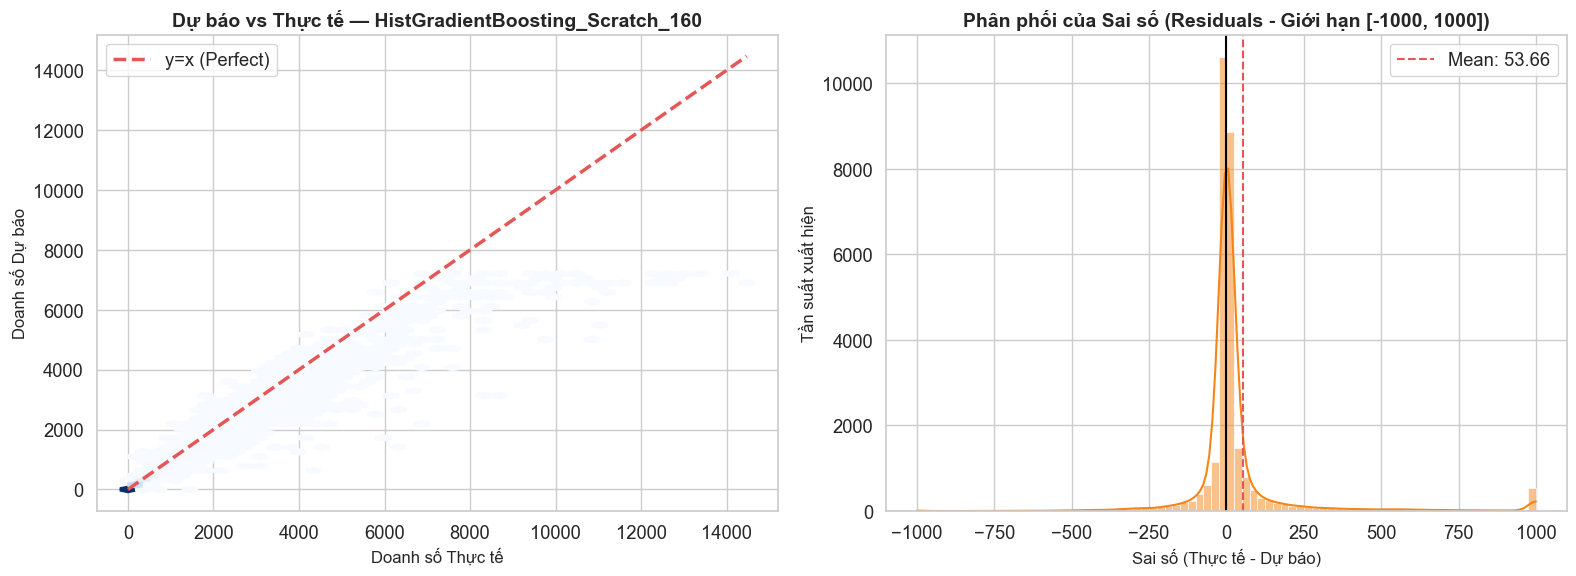

In [90]:
valid_diagnostics = valid_df[["date", "store_nbr", "family", TARGET]].copy()
valid_diagnostics["prediction"] = best_valid_pred
valid_diagnostics["residual"] = valid_diagnostics[TARGET] - valid_diagnostics["prediction"]

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Lấy mẫu vẽ
sample = valid_diagnostics.sample(n=min(15_000, len(valid_diagnostics)), random_state=RANDOM_STATE)

# 1. Scatter predicted vs actual sử dụng hexbin để biểu diễn mật độ điểm tốt hơn
axes[0].hexbin(sample[TARGET], sample["prediction"], gridsize=40, cmap="Blues", mincnt=1)
max_value = max(float(sample[TARGET].max()), float(sample["prediction"].max()))
axes[0].plot([0, max_value], [0, max_value], color=COLORS["accent"], linewidth=2.5, linestyle="--", label="y=x (Perfect)")
axes[0].set_title(f"Dự báo vs Thực tế — {best_model_name}")
axes[0].set_xlabel("Doanh số Thực tế")
axes[0].set_ylabel("Doanh số Dự báo")
axes[0].legend()

# 2. Histogram residual kèm KDE line
sns.histplot(valid_diagnostics["residual"].clip(-1000, 1000), bins=80, color=COLORS["secondary"], edgecolor="white", ax=axes[1], kde=True)
axes[1].axvline(0, color="black", linewidth=1.5, linestyle="-")
res_mean = valid_diagnostics["residual"].mean()
axes[1].axvline(res_mean, color=COLORS["accent"], linewidth=1.5, linestyle="--", label=f"Mean: {res_mean:.2f}")
axes[1].set_title("Phân phối của Sai số (Residuals - Giới hạn [-1000, 1000])")
axes[1].set_xlabel("Sai số (Thực tế - Dự báo)")
axes[1].set_ylabel("Tần suất xuất hiện")
axes[1].legend()

plt.tight_layout()
plt.show()


### 8.2 — Sai số theo Thời gian & Phân loại Cửa hàng
Kiểm tra xem mô hình có xu hướng dự báo lệch (lệch âm/lệch dương) theo từng ngày trong chuỗi thời gian validation (16 ngày) hoặc đối với từng nhóm cửa hàng cụ thể hay không.

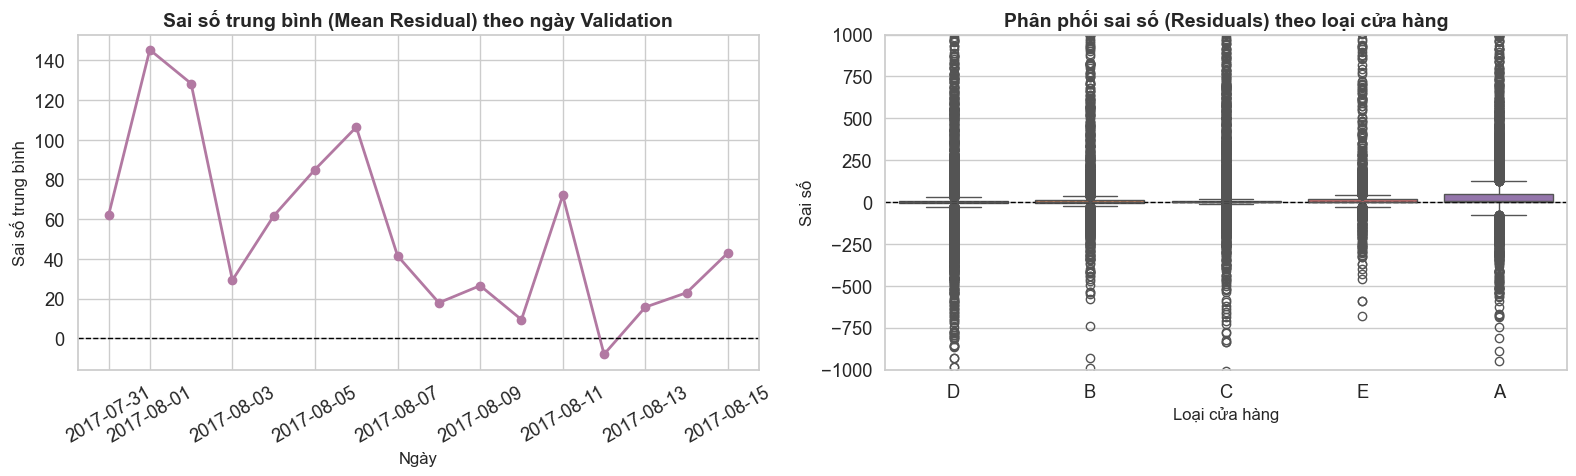

In [91]:
valid_diagnostics_store = valid_diagnostics.merge(stores, on="store_nbr", how="left")

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# 1. Sai số trung bình theo ngày validation
daily_res = valid_diagnostics_store.groupby("date")["residual"].mean().reset_index()
axes[0].plot(daily_res["date"], daily_res["residual"], marker="o", color=COLORS["purple"], linewidth=2)
axes[0].axhline(0, color="black", linestyle="--", linewidth=1)
axes[0].set_title("Sai số trung bình (Mean Residual) theo ngày Validation")
axes[0].set_xlabel("Ngày")
axes[0].set_ylabel("Sai số trung bình")
axes[0].tick_params(axis="x", rotation=30)

# 2. Phân phối sai số theo Loại cửa hàng
sns.boxplot(data=valid_diagnostics_store, x="type", y="residual", ax=axes[1], palette="muted", hue="type", legend=False)
axes[1].axhline(0, color="black", linestyle="--", linewidth=1)
axes[1].set_ylim(-1000, 1000)
axes[1].set_title("Phân phối sai số (Residuals) theo loại cửa hàng")
axes[1].set_xlabel("Loại cửa hàng")
axes[1].set_ylabel("Sai số")

plt.tight_layout()
plt.show()


### 8.3 — Tầm quan trọng của Đặc trưng (Feature Importance) & Sai số theo Nhóm sản phẩm
Xác định các thuộc tính có ảnh hưởng lớn nhất đối với mô hình dự báo, đồng thời tìm ra các nhóm sản phẩm có sai số MAE cao nhất để đề xuất hướng cải thiện.

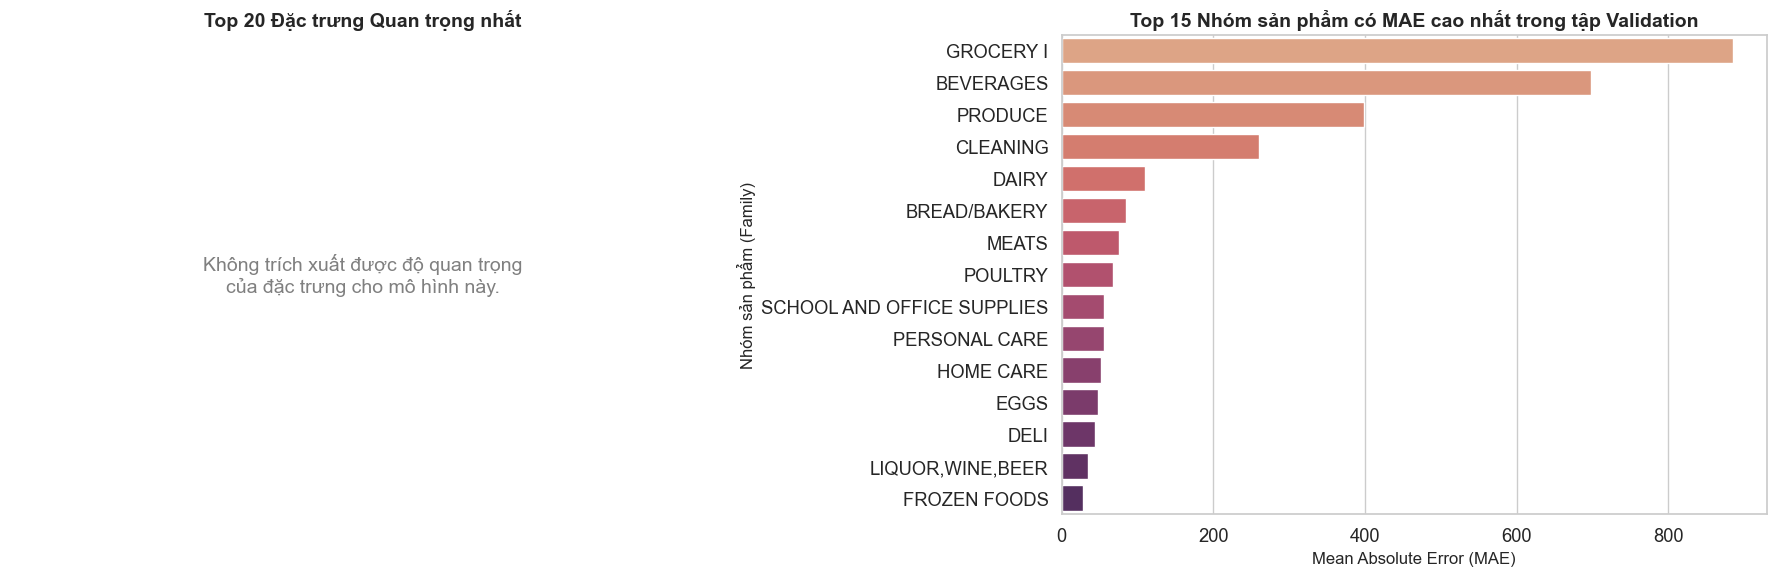

In [92]:
# 1. Feature Importance
best_estimator = models[best_model_name]
feature_imp = None
if hasattr(best_estimator, "named_steps"):
    step_name = "regressor" if "regressor" in best_estimator.named_steps else "model"
    if step_name in best_estimator.named_steps:
        reg = best_estimator.named_steps[step_name]
        if hasattr(reg, "feature_importances_"):
            feature_imp = reg.feature_importances_
        elif hasattr(reg, "coef_"):
            feature_imp = np.abs(reg.coef_)
        
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

if feature_imp is not None:
    imp_df = pd.DataFrame({"Feature": FEATURE_COLUMNS, "Importance": feature_imp})
    imp_df = imp_df.sort_values(by="Importance", ascending=False).head(20)
    
    sns.barplot(data=imp_df, x="Importance", y="Feature", ax=axes[0], palette="viridis", hue="Feature", legend=False)
    axes[0].set_title("Top 20 Đặc trưng Quan trọng nhất")
    axes[0].set_xlabel("Độ quan trọng")
    axes[0].set_ylabel("Tên đặc trưng")
else:
    axes[0].text(0.5, 0.5, "Không trích xuất được độ quan trọng\ncủa đặc trưng cho mô hình này.", 
                ha="center", va="center", fontsize=14, color="gray")
    axes[0].set_title("Top 20 Đặc trưng Quan trọng nhất")
    axes[0].axis("off")
    
# 2. Sai số MAE theo nhóm sản phẩm (Family)
family_error = (
    valid_diagnostics.assign(abs_error=lambda frame: frame["residual"].abs())
    .groupby("family", observed=True)
    .agg(MAE=("abs_error", "mean"), sales=(TARGET, "sum"))
    .sort_values("MAE", ascending=False)
    .head(15)
    .reset_index()
)

sns.barplot(data=family_error, x="MAE", y="family", ax=axes[1], palette="flare", hue="family", legend=False)
axes[1].set_title("Top 15 Nhóm sản phẩm có MAE cao nhất trong tập Validation")
axes[1].set_xlabel("Mean Absolute Error (MAE)")
axes[1].set_ylabel("Nhóm sản phẩm (Family)")

plt.tight_layout()
plt.show()


## Bước 9. Train final model và tạo submission trong notebook

Cell dưới đây train lại model tốt nhất trên 365 ngày cuối của train và tạo dataframe `submission` cho `test.csv`.

Theo yêu cầu, notebook chỉ tạo dataframe `submission` để xem trực tiếp trong notebook và không tự ghi submission/model/metrics ra `artifacts`.

In [93]:
def build_train_test_feature_frames() -> tuple[pd.DataFrame, pd.DataFrame]:
    train_part = train.copy()
    test_part = test.copy()
    test_part[TARGET] = np.nan
    combined = pd.concat([train_part, test_part], ignore_index=True, sort=False)
    combined_features = build_feature_frame(combined)
    train_features = combined_features[combined_features["id"].isin(train["id"])].copy()
    test_features = combined_features[combined_features["id"].isin(test["id"])].copy()
    return train_features, test_features


full_train_features, test_features = build_train_test_feature_frames()
final_fit_start = full_train_features[DATE_COLUMN].max() - pd.Timedelta(days=RECENT_TRAIN_DAYS)
final_fit_df = full_train_features[full_train_features[DATE_COLUMN] >= final_fit_start].copy()

print("Final fit rows:", final_fit_df.shape)
print("Test feature rows:", test_features.shape)

Final fit rows: (650430, 24)
Test feature rows: (28512, 24)


In [94]:
final_model = models[best_model_name]
final_model.fit(final_fit_df[FEATURE_COLUMNS], np.log1p(final_fit_df[TARGET]))
test_pred = np.clip(np.expm1(final_model.predict(test_features[FEATURE_COLUMNS])), 0, None)

submission = test_features[["id"]].copy()
submission[TARGET] = test_pred
submission = submission.sort_values("id")

display(submission.head())
display(submission[TARGET].describe().to_frame("predicted_sales"))

,id,sales
3000888,3000888,3.7317
3000889,3000889,0.1472
3000890,3000890,4.8090
3000891,3000891,"2,093.9001"
3000892,3000892,0.2307


,predicted_sales
count,"28,512.0000"
mean,410.7988
std,"1,012.6635"
min,0.1424
25%,3.9793
50%,28.2981
75%,261.8660
max,"7,240.9287"


## Bước 10. Tổng kết

Notebook này dùng đúng dạng dữ liệu demand forecasting hơn dataset cũ. Với validation 16 ngày cuối, mô hình HistGradientBoosting trên `log1p(sales)` và các đặc trưng lag/rolling thắng rõ rệt so với baseline time-series.

Các điểm có thể cải thiện tiếp:

- Tuning thêm HistGradientBoosting hoặc dùng LightGBM/XGBoost nếu môi trường cho phép.
- Tạo thêm lag theo mùa vụ như 7, 14, 21, 365 ngày khi bài toán cho phép recursive forecast.
- Xử lý holiday theo `locale` kỹ hơn thay vì gom thành cờ holiday toàn cục.
- Huấn luyện riêng theo nhóm sản phẩm lớn hoặc store cluster nếu muốn tối ưu sâu hơn.